Polarized Proton Data

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 265,730 (1.01 MB)

 Trainable params: 265,730 (1.01 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4402 - val_loss: 0.1508
Epoch 2/1000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0333 - val_loss: -0.0423
Epoch 3/1000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: -0.1472 - val_loss: -0.1977
Epoch 4/1000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: -0.3026 - val_loss: -0.3601
Epoch 5/1000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: -0.4597 - val_loss: -0.5238
Epoch 6/1000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: -0.5909 - val_loss: -0.6564
Epoch 7/1000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: -0.7189 - val_loss: -0.7485
Epoch 8/1000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: -0.7672 - val_loss: -0.8274
Epoch 9/1000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: -0.8059 - val_loss: -0.8507
Epoch 10/1000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: -0.8578 - val_loss: -0.8413
Epoch 11/1000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: -0.8806 - val_loss: -0.8514
Epoch 12/1000
19/19 ━━━━━━━━━━━━━

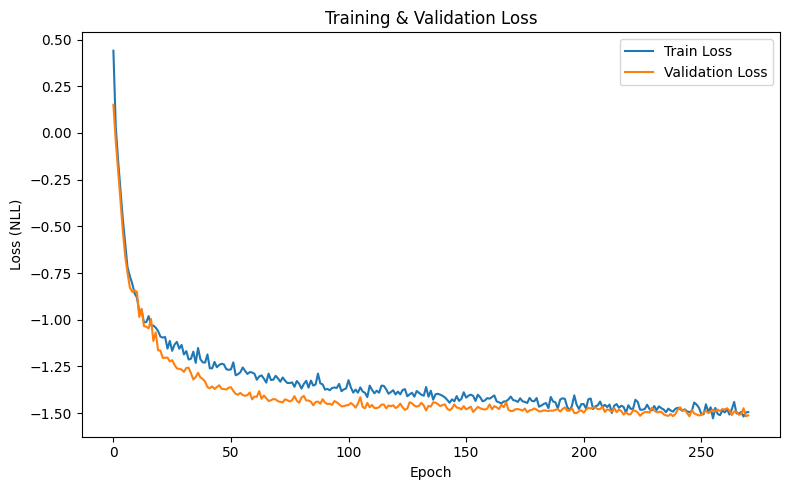

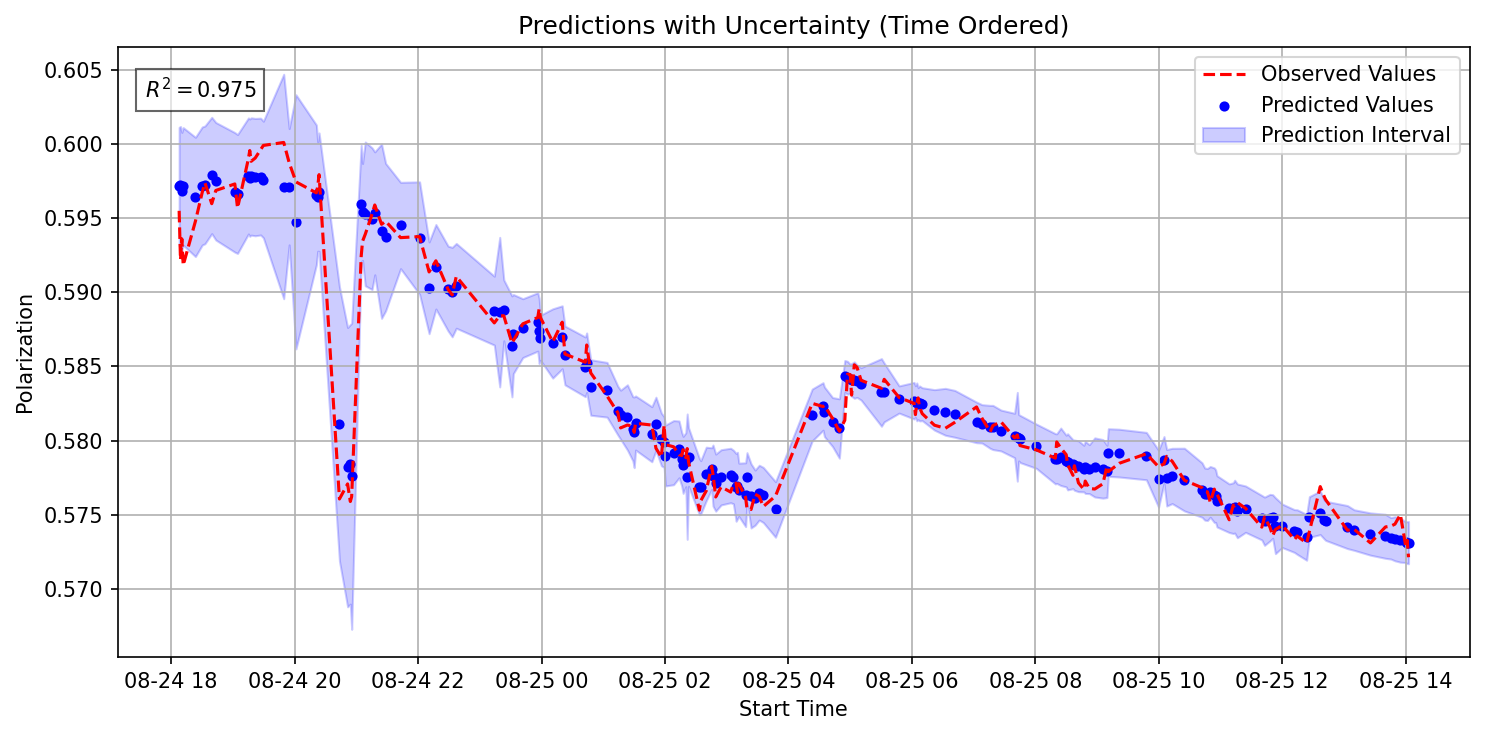

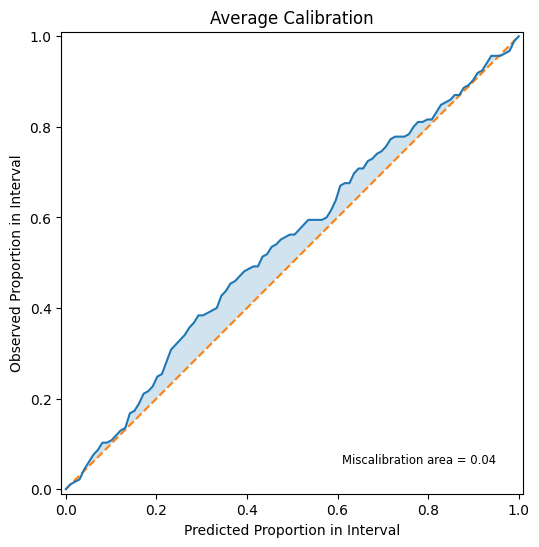

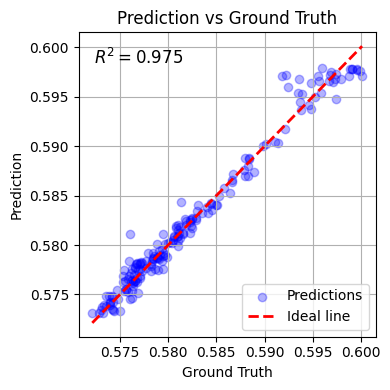

In [3]:
# ------------------------
# 0. Imports
# ------------------------
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, Normalization
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import uncertainty_toolbox as uct

# ------------------------
# 1. Load and prepare data
# ------------------------
polarized_proton = pd.read_csv("polarized_proton_data_with_current.csv")

# Filter sample P07
data = polarized_proton[polarized_proton['SampleID'].astype(str).str.strip() == '(P07)'].reset_index(drop=True)

# Convert time columns to datetime (keep invalids as NaT, no dropping here)
if 'start_time' in data.columns:
    data['start_time'] = pd.to_datetime(data['start_time'], errors='coerce')
if 'end_time' in data.columns:
    data['end_time'] = pd.to_datetime(data['end_time'], errors='coerce')

# Features and target
feature_cols = ['uwave_freq', 'TGT:PT12:Target_Dose', 'scaler_calc1']
target_col = 'polarization'

X = tf.convert_to_tensor(data[feature_cols].values, dtype=tf.float32)
y = tf.abs(tf.convert_to_tensor(data[target_col].values, dtype=tf.float32))

# ------------------------
# 2. Train-test split with reproducible seed
# ------------------------
dataset_size = X.shape[0]
indices = tf.range(dataset_size)

# reproducibility like random_state=42
tf.random.set_seed(42)
shuffled_indices = tf.random.shuffle(indices, seed=42)

split = int(0.8 * dataset_size)
train_indices = shuffled_indices[:split]
test_indices = shuffled_indices[split:]

# keep numpy indices for pandas
train_idx_np = train_indices.numpy()
test_idx_np = test_indices.numpy()

X_train, X_test = tf.gather(X, train_indices), tf.gather(X, test_indices)
y_train, y_test = tf.gather(y, train_indices), tf.gather(y, test_indices)

# ------------------------
# 3. Feature normalization
# ------------------------
normalizer = Normalization(axis=-1)
normalizer.adapt(X_train)

X_train_scaled = normalizer(X_train)
X_test_scaled = normalizer(X_test)

# Target normalization
y_mean = tf.reduce_mean(y_train)
y_std = tf.math.reduce_std(y_train)
y_train_scaled = (y_train - y_mean) / y_std

# ------------------------
# 4. Define NLL Gaussian loss
# ------------------------
def nll_gaussian(y_true, y_pred):
    mean = y_pred[:, 0]
    log_var = tf.clip_by_value(y_pred[:, 1], -10.0, 10.0)
    precision = tf.exp(-log_var)
    return tf.reduce_mean(0.5 * (log_var + tf.square(y_true - mean) * precision))

# ------------------------
# 5. Build the model
# ------------------------
input_dim = X_train_scaled.shape[1]

model = Sequential([
    Input(shape=(input_dim,)),
    Dense(512, activation='relu'),
    Dropout(0.1),
    Dense(512, activation='relu'),
    Dropout(0.1),
    Dense(2, bias_initializer=tf.keras.initializers.Constant([0.0, -1.0]))  # [mean, log_var]
])

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
model.compile(optimizer=optimizer, loss=nll_gaussian)
model.summary()

# ------------------------
# 6. Train the model
# ------------------------
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=25,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train_scaled, y_train_scaled,
    epochs=1000,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# ------------------------
# 7. Make predictions
# ------------------------
preds_scaled = model(X_test_scaled)
pred_mean_scaled = preds_scaled[:, 0]
pred_log_var = tf.clip_by_value(preds_scaled[:, 1], -10.0, 10.0)
pred_std_scaled = tf.sqrt(tf.exp(pred_log_var))

# Inverse transform predictions
pred_mean = pred_mean_scaled * y_std + y_mean
pred_std = pred_std_scaled * y_std

# ------------------------
# 8. Prepare DataFrame for plotting
# ------------------------
X_test_final = data.iloc[test_idx_np][['start_time', 'end_time', 'RunNumber']].copy()
X_test_final['Polarization_GT'] = y_test.numpy()
X_test_final['Polarization_Prediction'] = pred_mean.numpy()
X_test_final['Polarization_Prediction_std'] = pred_std.numpy()

# Sort by start_time if available
if 'start_time' in X_test_final.columns:
    X_test_final = X_test_final.sort_values('start_time').reset_index(drop=True)

# ------------------------
# 9. R² Calculation
# ------------------------
r2 = r2_score(X_test_final['Polarization_GT'], X_test_final['Polarization_Prediction'])
print(f"R²: {r2:.3f}")

# ------------------------
# 10. Plot Training Loss
# ------------------------
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (NLL)')
plt.title('Training & Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------
# 11. Plot Predictions with Uncertainty (ordered by time)
# ------------------------
fig, ax = plt.subplots(figsize=(10,5), dpi=150)

ax.plot(
    X_test_final['start_time'],
    X_test_final['Polarization_GT'],
    'r--', label='Observed Values'
)
ax.scatter(
    X_test_final['start_time'],
    X_test_final['Polarization_Prediction'],
    s=15, color='blue', label='Predicted Values'
)
ax.fill_between(
    X_test_final['start_time'],
    X_test_final['Polarization_Prediction'] - 2*X_test_final['Polarization_Prediction_std'],
    X_test_final['Polarization_Prediction'] + 2*X_test_final['Polarization_Prediction_std'],
    color='blue', alpha=0.2, label='Prediction Interval'
)

ax.set_xlabel("Start Time")
ax.set_ylabel("Polarization")
ax.set_title("Predictions with Uncertainty (Time Ordered)")
ax.legend()
ax.grid(True)
ax.text(
    0.02, 0.95, f"$R^2 = {r2:.3f}$",
    transform=ax.transAxes,
    fontsize=10, verticalalignment='top',
    bbox=dict(facecolor='white', alpha=0.6)
)

plt.tight_layout()
plt.savefig("prediction_intervals_P07_tf_time.png", dpi=300, bbox_inches='tight')
plt.show()

# ------------------------
# 12. Average Calibration Plot
# ------------------------
uct.viz.plot_calibration(
    X_test_final['Polarization_Prediction'].values,
    X_test_final['Polarization_Prediction_std'].values,
    X_test_final['Polarization_GT'].values
)
plt.gcf().set_size_inches(6,6)
plt.title("Average Calibration")
plt.show()

# ------------------------
# 13. Prediction vs Ground Truth Scatter Plot
# ------------------------
plt.figure(figsize=(4,4))
plt.scatter(
    X_test_final['Polarization_GT'],
    X_test_final['Polarization_Prediction'],
    alpha=0.3, color='blue', label='Predictions'
)
plt.plot(
    [X_test_final['Polarization_GT'].min(), X_test_final['Polarization_GT'].max()],
    [X_test_final['Polarization_GT'].min(), X_test_final['Polarization_GT'].max()],
    'r--', lw=2, label="Ideal line"
)
plt.text(0.05, 0.95, f"$R^2 = {r2:.3f}$",
         transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top')
plt.xlabel("Ground Truth")
plt.ylabel("Prediction")
plt.title("Prediction vs Ground Truth")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [4]:
X_test_final

,start_time,end_time,RunNumber,Polarization_GT,Polarization_Prediction,Polarization_Prediction_std
0,2022-08-24 18:07:46.285944,2022-08-24 18:09:05.502277+00:00,16767.0,0.595506,0.597149,0.001996
1,2022-08-24 18:09:05.502557,2022-08-24 18:10:24.716372+00:00,16767.0,0.592202,0.597229,0.001984
2,2022-08-24 18:10:24.722661,2022-08-24 18:11:43.932227+00:00,16767.0,0.593614,0.596812,0.001993
3,2022-08-24 18:11:43.932456,2022-08-24 18:13:03.147190+00:00,16767.0,0.591829,0.597153,0.001985
4,2022-08-24 18:23:36.911184,2022-08-24 18:24:56.120785+00:00,16767.0,0.594808,0.596444,0.002013
...,...,...,...,...,...,...
180,2022-08-25 13:49:32.524291,2022-08-25 13:50:51.738289+00:00,16772.0,0.574358,0.573370,0.000743
181,2022-08-25 13:54:49.405597,2022-08-25 13:56:08.613962+00:00,16772.0,0.575006,0.573289,0.000749
182,2022-08-25 14:00:06.316997,2022-08-25 14:01:25.527131+00:00,16772.0,0.572842,0.573130,0.000682
183,2022-08-25 14:01:25.533144,2022-08-25 14:02:44.742191+00:00,16772.0,0.573265,0.573116,0.000708
